# The commodity fund that dodges the "contango tax" 🛢️
### Optimized-roll vs front-month — USCI vs DBC, GSG, DJP, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

A commodity index is a stack of **futures**. Futures expire, so every month the fund has to **roll** — sell the contract about to expire and buy a later one. When later contracts cost *more* (a shape called **contango**), that roll quietly loses money, over and over. It's the **contango tax**, and for a naive front-month index it can eat several percent a year.

Some funds got clever: instead of always buying the very next contract, an **optimized-roll** index (like **USCI**) hunts along the curve for the *cheapest* contract to hold — and even picks the commodities whose curves currently pay you to hold them. The pitch: **same commodities, less tax, higher return**. We checked it on 16 years of real funds.

> 📓 **Plain-language layer.** Want the bootstrap CIs and HAC *t*-stats? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from opt_roll import data, strategy as st

BENCH = ["DBC", "GSG", "DJP"]
ERAS = [("deep-contango 2010-2015", "2010-09", "2015-12"),
        ("recovery 2016-2020", "2016-01", "2020-12"),
        ("backwardation 2021-2026", "2021-01", "2026-06")]
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    RETS = data.monthly_returns(PRICES, asof=data.AS_OF)
    EX = st.excess_frame(RETS, cash=data.CASH)
    COMMON = st.common_sample(EX, ["USCI"] + BENCH)
else:
    PRICES = RETS = EX = COMMON = None
print("real tape cached:", HAVE_REAL, "| common months:", (0 if COMMON is None else len(COMMON)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': '16935c3b46d8', 'n': 190, 'legs': {'USCI': {'ex': 3.61, 'vol': 14.7, 'sharpe': 0.245, 'tr': 3.95, 'dd': -64.0, 'er': 1.03}, 'DBC': {'ex': 2.34, 'vol': 17.2, 'sharpe': 0.136, 'tr': 2.24, 'dd': -64.8, 'er': 0.85}, 'GSG': {'ex': 1.14, 'vol': 21.3, 'sharpe': 0.053, 'tr': 0.18, 'dd': -78.2, 'er': 0.48}, 'DJP': {'ex': 0.67, 'vol': 16.5, 'sharpe': 0.04, 'tr': 0.66, 'dd': -69.4, 'er': 0.7}}, 'race': {'DBC': {'adv': 0.109, 'lo': -0.13, 'hi': 0.344, 'frac': 0.195, 'diff': 1.26, 't': 0.63}, 'GSG': {'adv': 0.191, 'lo': -0.069, 'hi': 0.433, 'frac': 0.075, 'diff': 2.47, 't': 0.94}, 'DJP': {'adv': 0.204, 'lo': -0.027, 'hi': 0.437, 'frac': 0.045, 'diff': 2.94, 't': 1.67}}, 'eras': ['deep-contango 2010-2015', 'recovery 2016-2020', 'backwardation 2021-2026'], 'era': {'DBC': [(4.95, 1.49, 0.247), (-7.22, -3.04, -0.48), (5.4, 1.75, 0.438)], 'GSG': [(7.49, 1.48, 0.321), (-3.32, -0.82, -0.265), (2.86, 0.76, 0.428)], 'DJP': [(6.91, 2.68, 0.383), (-4.79, -2.13, -0.341), (6.12, 2.01, 0.494)]}, 'costed': {'DBC': (0.094, 1.06, 0.53), 'GSG': (0.175, 2.27, 0.87), 'DJP': (0.197, 2.86, 1.63)}, 'pdbc': {'n': 139, 'adv': 0.101, 'lo': -0.051, 'hi': 0.245, 'diff': 1.31, 't': 0.65}, 'syn': [(0.0, 0.007, -0.079, 0.1, 0.1, 0.14), (3.0, 0.194, 0.109, 0.292, 3.1, 4.27)]}


real tape cached: True | common months: 190


## The answer first

| Question | Answer |
|---|---|
| Did the optimized fund beat the front-month ones? | **Yes, over the full 16 years** — USCI's return-per-unit-risk (Sharpe, above cash) was **+0.24** vs **+0.14** (DBC), **+0.05** (GSG) and **+0.04** (DJP). Right direction, and a smoother ride. |
| Is it a reliable edge? | **No.** The gap isn't statistically distinguishable from zero, and — the killer — it **flipped sign** by regime: USCI *lost* to every benchmark through 2016-2020 (by -7.2%/yr vs DBC). It wins in contango eras, loses in others. |
| So is it free money? | **No — it's a bet on the shape of the curve.** When curves are in contango the optimized rule pays; when the whole complex flips to backwardation or whipsaws, the clever screen can pick the wrong commodities. |
| Is this "timing the curve"? | Different. [35-contango](../../35-contango/README.md) moves *in and out* of the market on a curve signal. Here **both** funds stay fully invested — we just compare two ways of rolling. |

## 1 · The claim

> *"A front-month index rolls up a rising curve and bleeds the contango tax. An optimized-roll index picks the cheapest contract to hold and the most backwardated commodities, dodging the tax — so it earns a higher risk-adjusted return, structurally."*

This is real, textbook mechanics: the **roll yield**, not spot price moves, drives most of a commodity index's long-run return (Gorton-Rouwenhorst 2006, Erb-Harvey 2006). So *how* you roll genuinely matters. The question is whether the packaged optimized wrappers actually **deliver** a durable edge you can hold — or just a regime bet.

## 2 · One trick first — measure *above cash*

A commodity index is fully collateralised: it parks cash in **T-bills** and earns that yield *on top of* the commodity return. In 2023-26 that's ~5%/yr — and it's **the same for every fund**. If we compared raw returns, a high-interest-rate era would look like a commodity edge. So we subtract a T-bill fund (**BIL**) from *both* sides. What's left is only the **spot + roll** difference — exactly the thing the claim is about.

## 3 · The teardown — who won?

Excess-of-cash **Sharpe** (return per unit of risk, above T-bills), 2010-09 → 2026-06.

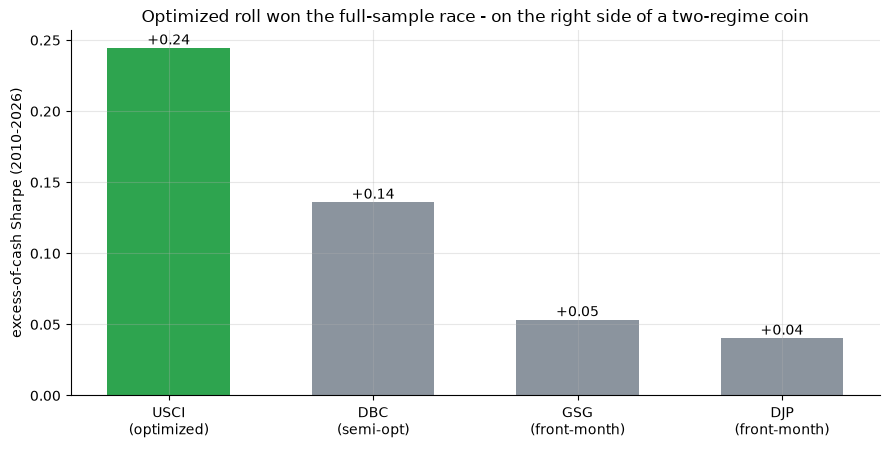

excess-of-cash Sharpe: {'USCI': 0.245, 'DBC': 0.136, 'GSG': 0.053, 'DJP': 0.04}


In [2]:
funds = ['USCI'] + BENCH
if HAVE_REAL:
    sh = []
    for f in funds:
        if f == 'USCI':
            sh.append(st.annualized_sharpe(COMMON['USCI'].to_numpy())); continue
        sh.append(st.sharpe_race(EX, 'USCI', f)['sharpe_bench'])
    sh[0] = st.annualized_sharpe(COMMON['USCI'].to_numpy())
else:
    sh = [R['legs'][f]['sharpe'] for f in funds]
colors = [GREEN, GREY, GREY, GREY]
labels = ['USCI\n(optimized)', 'DBC\n(semi-opt)', 'GSG\n(front-month)', 'DJP\n(front-month)']
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.bar(labels, sh, color=colors, width=.6)
for i, v in enumerate(sh): ax.annotate(f'{v:+.2f}', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.6); ax.set_ylabel('excess-of-cash Sharpe (2010-2026)')
ax.set_title('Optimized roll won the full-sample race - on the right side of a two-regime coin')
plt.tight_layout(); plt.show()
print('excess-of-cash Sharpe:', {f: round(v,3) for f, v in zip(funds, sh)})

USCI (green) sits clearly above the three front-ish rollers. It also rode gentler: its worst drawdown was **-64%** vs GSG's brutal **-78%**. So far, the optimized story looks great.

**But is the edge reliable?** Here's the same race, split into three eras of the commodity cycle.

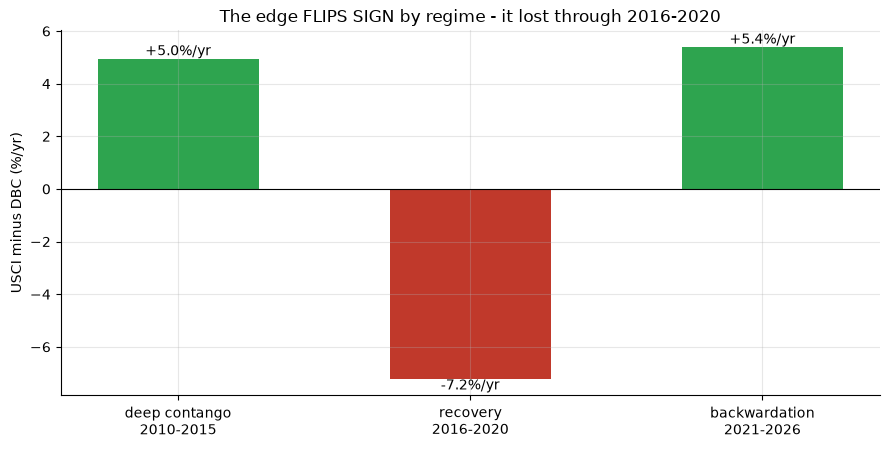

USCI - DBC by era (%/yr): [5.0, -7.2, 5.4]


In [3]:
if HAVE_REAL:
    rows = st.era_race(EX, 'USCI', 'DBC', ERAS)
    diffs = [r['diff_ann_pct'] for r in rows]
else:
    diffs = [e[0] for e in R['era']['DBC']]
labels = ['deep contango\n2010-2015', 'recovery\n2016-2020', 'backwardation\n2021-2026']
colors = [GREEN if d > 0 else RED for d in diffs]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.bar(labels, diffs, color=colors, width=.55)
for i, v in enumerate(diffs): ax.annotate(f'{v:+.1f}%/yr', (i, v), ha='center', va='bottom' if v>0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('USCI minus DBC (%/yr)')
ax.set_title('The edge FLIPS SIGN by regime - it lost through 2016-2020')
plt.tight_layout(); plt.show()
print('USCI - DBC by era (%/yr):', [round(d,1) for d in diffs])

There it is. USCI **beat** DBC by ~5%/yr when curves were deep in contango (2010-2015) and again in the 2021+ inflation surge — but **lost by -7.2%/yr through 2016-2020** (and that loss is statistically real, not noise — see the quants notebook). An edge that turns significantly *negative* for a whole five-year stretch isn't a durable premium; it's a **bet on the shape of the futures curve**.

## 4 · A sanity check on our own tools

Before trusting any of this, we feed the machinery a **made-up world where we planted a real +3%/yr roll edge** — and a twin world with **no edge at all**. The tool must find the first and stay silent on the second.

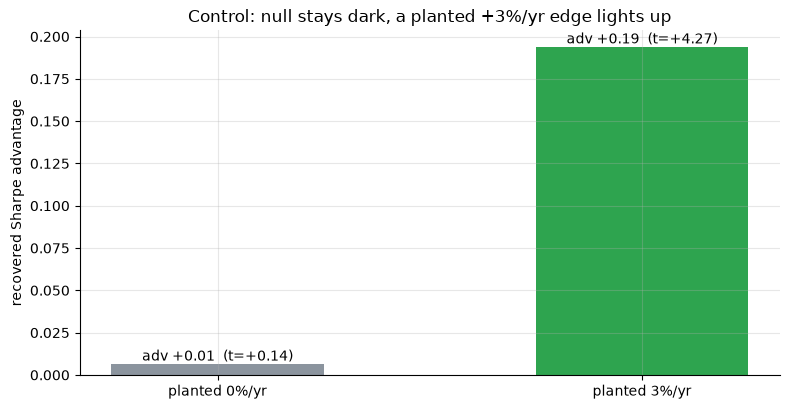

planted +0%/yr -> Sharpe adv +0.007, return diff +0.10%/yr (t=+0.14)
planted +3%/yr -> Sharpe adv +0.194, return diff +3.10%/yr (t=+4.27)


In [4]:
res = []
for edge in (0.0, 0.03):
    w = data.synthetic_world(roll_edge_annual=edge, seed=908)
    d = st.synthetic_detect(w)
    res.append((edge*100, d['sharpe_adv'], d['diff_ann_pct'], d['t_diff']))
labels = [f'planted {int(e)}%/yr' for e,_,_,_ in res]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(labels, [r[1] for r in res], color=[GREY, GREEN], width=.5)
for i,(e,a,df_,t) in enumerate(res): ax.annotate(f'adv {a:+.2f}  (t={t:+.2f})',(i,a),ha='center',va='bottom')
ax.set_ylabel('recovered Sharpe advantage'); ax.axhline(0,c='k',lw=.6)
ax.set_title('Control: null stays dark, a planted +3%/yr edge lights up')
plt.tight_layout(); plt.show()
for e,a,df_,t in res: print(f'planted {e:+.0f}%/yr -> Sharpe adv {a:+.3f}, return diff {df_:+.2f}%/yr (t={t:+.2f})')

With **no** planted edge the tool reads a Sharpe advantage of ~0 (*t* = +0.14); with a genuine **+3%/yr** it lights up at *t* = +4.27. So the machinery would *happily* certify a real, constant roll edge at this sample size. It doesn't — because on the real tape the edge isn't constant.

## 5 · The verdict

- **Signal — Weak.** USCI beat every front-month benchmark on excess-of-cash Sharpe over 16 years (**+0.24** vs +0.14/+0.05/+0.04) — right direction — but the gap isn't statistically solid and it **flips sign by regime** (it lost 2016-2020). Directionally sensible, not reliably real.
- **Tradability — Mirage.** Costs don't kill it (both are buy-and-hold), and USCI even ended ahead with a shallower drawdown — but there's no *bankable* roll edge: the advantage could be zero, the sign depends on the regime, and a chunk of USCI's smoother ride is just its lighter energy weight (lower risk), not paid roll yield. A regime bet wearing a free-lunch label.

## 6 · Going further 🚪

- **The tax is real; the wrapper edge isn't durable.** Front-month indices really do bleed roll yield in contango — but the optimized fix only pays *while curves are in contango*.
- **Watch the composition.** USCI holds far less energy than GSG, so its lower volatility is partly a diversification choice, not a roll victory. Compare like with like.
- **Cousins on the desk.** [35-contango](../../35-contango/README.md) *times* the curve; [794-commodity-carry](../../794-commodity-carry/README.md) sorts single commodities on carry; [661-uso-roll-decay](../../661-uso-roll-decay/README.md) is the roll tax on a single-commodity fund (USO).

*Think USCI is simply the better commodity fund? Re-read the 2016-2020 bar — then ask which regime the next decade will be in.*